# 01 - Baseline EDA & Preprocessing

This notebook sets up our baseline models to classify Quasars using photometry.

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, confusion_matrix, 
    roc_curve, precision_recall_curve, classification_report
)

# Helper for saving metrics
sys.path.append('../src')
from evaluation import save_metrics

## 1. Load Dataset
We load the SDSS dataset. 

In [3]:
data_path = '../data/raw/Skyserver_Cross.csv'

df = pd.read_csv(data_path)
print(f'Dataset loaded. Shape: {df.shape}')


Dataset loaded. Shape: (500000, 7)


## 2. Target Formulation
Merge STAR and GALAXY into 0, and keep QSO as 1.

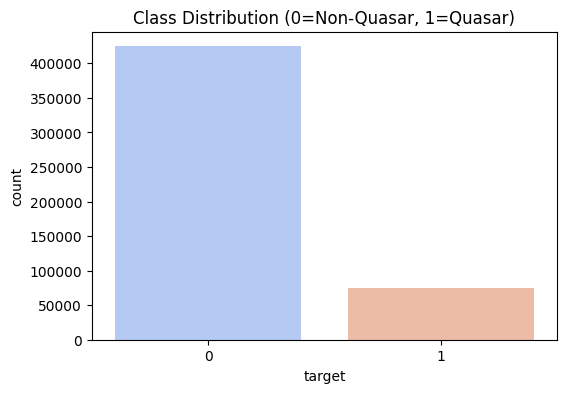

In [4]:
df['target'] = (df['class'] == 'QSO').astype(int)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='target', hue='target', palette='coolwarm', legend=False)
plt.title('Class Distribution (0=Non-Quasar, 1=Quasar)')
plt.show()

## 3. Feature Engineering
Creating color indices (differences in bands) since they represent the shape of the object's spectrum.

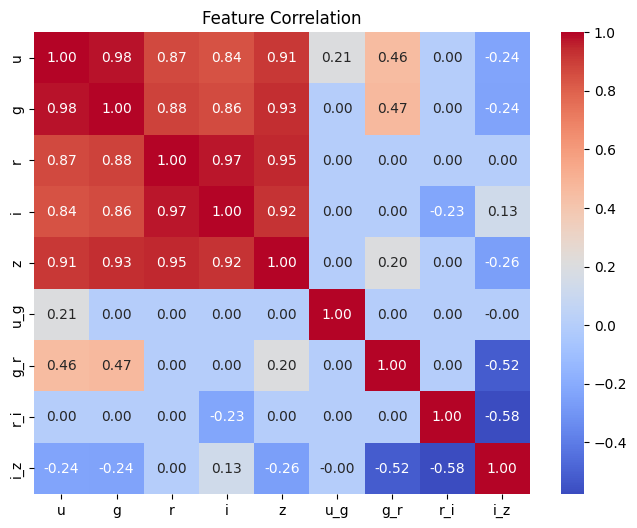

In [22]:
df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation')
plt.show()

## 4. Data Splitting & Scaling


In [17]:
X = df[features]
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train Shape:", X_train_scaled.shape)
print("Test Shape:", X_test_scaled.shape)

Train Shape: (400000, 4)
Test Shape: (100000, 4)


## 5. Helper Functions
A quick function to plot the Confusion Matrix, ROC, and PR curves for any model.

In [7]:
# We will collect metrics here to save later
all_metrics = []

def evaluate_model(model_name, y_true, y_pred, y_prob):
    print(f"--- {model_name} ---")
    print(classification_report(y_true, y_pred))
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    
    # PR Curve
    if y_prob is not None:
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        pr_score = average_precision_score(y_true, y_prob)
        axes[1].plot(recall, precision, label=f'PR-AUC={pr_score:.3f}', color='darkorange')
        axes[1].set_title('PR Curve')
        axes[1].legend()
        
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_score = roc_auc_score(y_true, y_prob)
        axes[2].plot(fpr, tpr, label=f'ROC-AUC={roc_score:.3f}', color='green')
        axes[2].plot([0,1], [0,1], 'k--')
        axes[2].set_title('ROC Curve')
        axes[2].legend()
        
        # Save metrics
        all_metrics.append({
            'model': model_name, 'experiment': 'baseline',
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1_score': f1_score(y_true, y_pred, zero_division=0),
            'roc_auc': roc_score, 'pr_auc': pr_score
        })
    plt.tight_layout()
    plt.show()

## 6. Logistic Regression
Trained on the **Full Dataset**.

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     84921
           1       0.63      0.18      0.28     15079

    accuracy                           0.86    100000
   macro avg       0.75      0.58      0.60    100000
weighted avg       0.83      0.86      0.83    100000



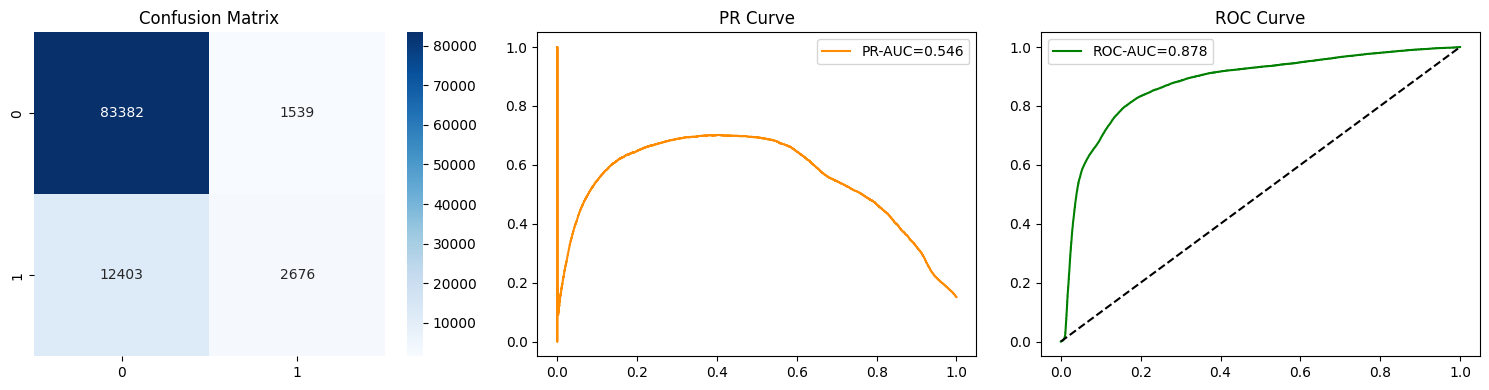

In [8]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_full_scaled, y_train_full)

y_pred_lr = lr.predict(X_test_full_scaled)
y_prob_lr = lr.predict_proba(X_test_full_scaled)[:, 1]

evaluate_model('Logistic Regression', y_test_full, y_pred_lr, y_prob_lr)

## 7. Decision Tree
Trained on the **Full Dataset**.

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     84921
           1       0.83      0.75      0.79     15079

    accuracy                           0.94    100000
   macro avg       0.89      0.86      0.88    100000
weighted avg       0.94      0.94      0.94    100000



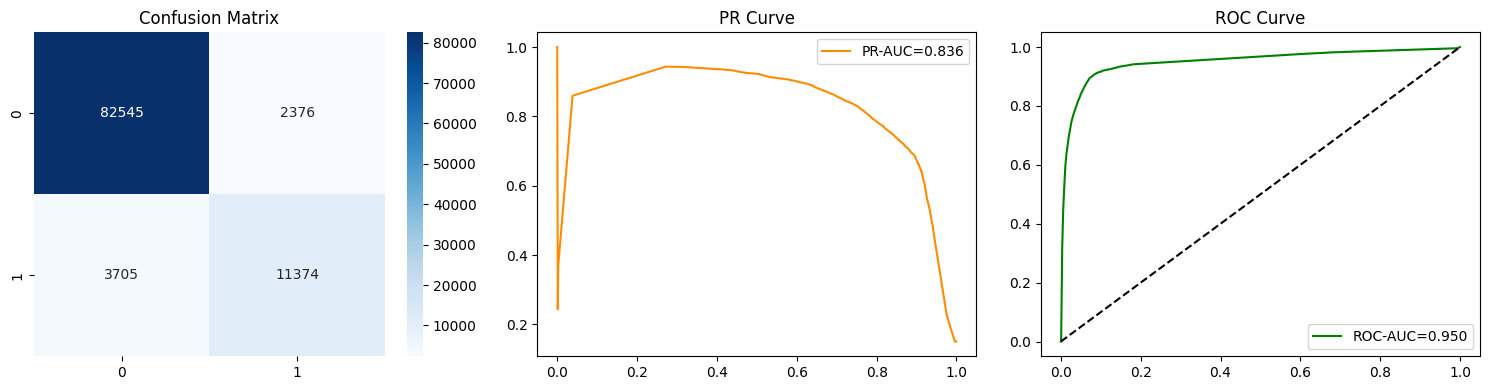

In [9]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_full_scaled, y_train_full)

y_pred_dt = dt.predict(X_test_full_scaled)
y_prob_dt = dt.predict_proba(X_test_full_scaled)[:, 1]

evaluate_model('Decision Tree', y_test_full, y_pred_dt, y_prob_dt)

## 8. Random Forest
Trained on the **Full Dataset**. Often the strongest baseline.

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     84921
           1       0.83      0.77      0.80     15079

    accuracy                           0.94    100000
   macro avg       0.90      0.87      0.88    100000
weighted avg       0.94      0.94      0.94    100000



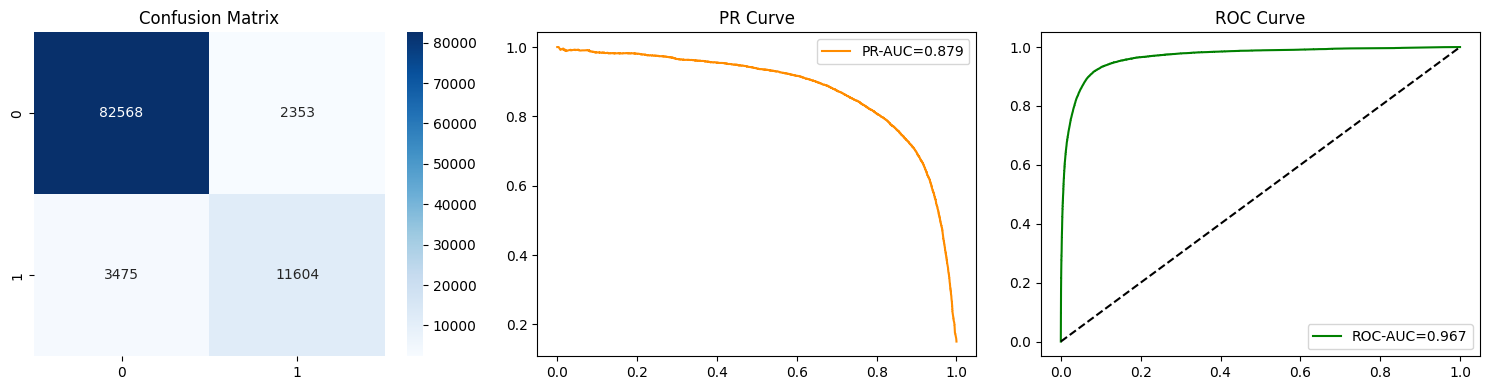

In [10]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_full_scaled, y_train_full)

y_pred_rf = rf.predict(X_test_full_scaled)
y_prob_rf = rf.predict_proba(X_test_full_scaled)[:, 1]

evaluate_model('Random Forest', y_test_full, y_pred_rf, y_prob_rf)

## 9. K-Nearest Neighbors (KNN)
Trained on the **Subsampled Dataset** (distance calculations are slow).

--- KNN ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      8492
           1       0.81      0.74      0.78      1508

    accuracy                           0.94     10000
   macro avg       0.88      0.86      0.87     10000
weighted avg       0.93      0.94      0.93     10000



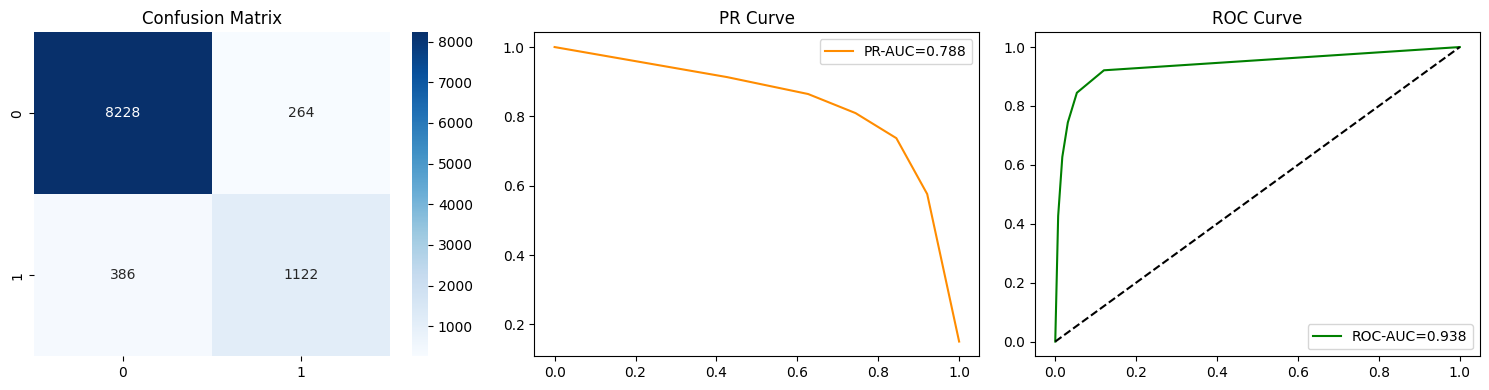

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sub_scaled, y_train_sub)

y_pred_knn = knn.predict(X_test_sub_scaled)
y_prob_knn = knn.predict_proba(X_test_sub_scaled)[:, 1]

evaluate_model('KNN', y_test_sub, y_pred_knn, y_prob_knn)

## 10. Support Vector Machine (SVM)
Trained on the **Subsampled Dataset** (SVM scaling is $O(N^3)$).

--- SVM ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      8492
           1       0.86      0.73      0.79      1508

    accuracy                           0.94     10000
   macro avg       0.90      0.85      0.88     10000
weighted avg       0.94      0.94      0.94     10000



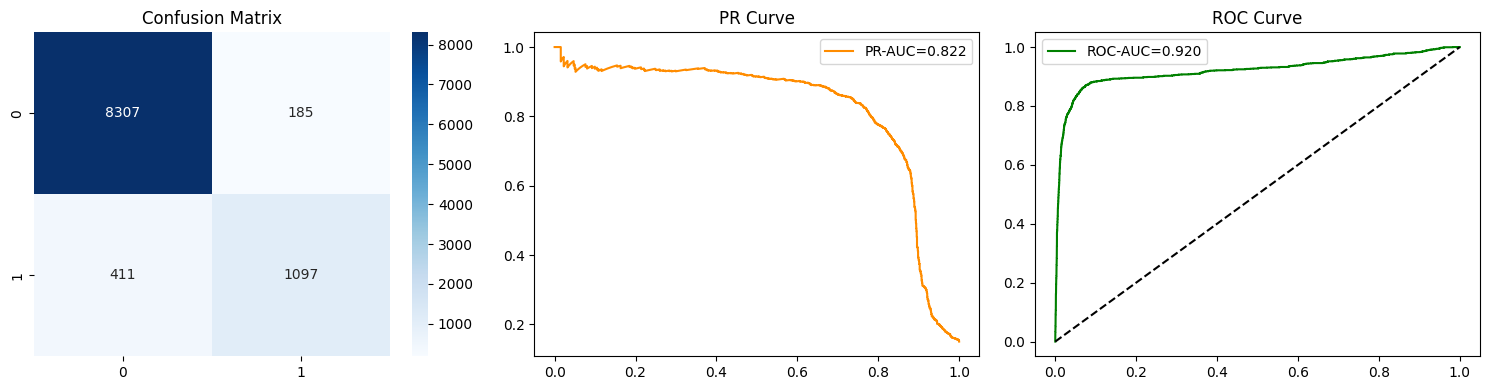

In [12]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_sub_scaled, y_train_sub)

y_pred_svm = svm.predict(X_test_sub_scaled)
y_prob_svm = svm.predict_proba(X_test_sub_scaled)[:, 1]

evaluate_model('SVM', y_test_sub, y_pred_svm, y_prob_svm)

## 11. Save Metrics
Saving the results to compare against advanced pipelines later.

In [13]:
# Save using the helper function
try:
    save_metrics(all_metrics, filename='baseline_metrics.csv', output_dir='../results/metrics')
    print("Metrics saved successfully.")
except Exception as e:
    print(f"Could not save metrics: {e}")

Metrics saved to ../results/metrics\baseline_metrics.csv
Metrics saved successfully.
